In [ ]:
#%%     Imports

%load_ext autoreload
%autoreload 2

# Standard Imports
import tensorflow as tf

tf.keras.backend.clear_session()
tf.keras.backend.set_floatx('float64')
tf_float = 'float64'
tf.random.set_seed(42)

import numpy as np
np_float = np.float64

import os
import datetime

# Own imports
import ContinuumMechanics as CM
import layers
import subANNs
import Outputs
import Plots
import Callbacks
import utils
import fit
import build


device = 'gpu:' + str(0) if tf.test.is_gpu_available() else 'cpu:0'

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


In [ ]:
dataset = 'Results_Liao_Thermo'

load_model = False
modelToLoad = '.\\Results_{:}\\20251127-173806'.format(dataset)

pathToData = '.\\datasets\\{:}_data\\'.format(dataset)   

if load_model: 
    outputFolder = modelToLoad
else:
    date = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    outputFolder = '.\\Results_{:}\\'.format(dataset) + date

if not os.path.exists(outputFolder):
    os.makedirs(outputFolder)


In [ ]:


incomp = True
visco = True

uncoupled = True # must be True, was only experementally tested
rateDependent = True

numDir = 0 # number $n$ of preferred material directions $\vec{m}$ (e.g. fibers) to be learned by the model
numTens = 1  # number $R$ of generalized Maxwell models $\tilde{\tns{L}}_r$ to be learned by the model
numExtra = 1 # number $n_f$ of features which parameterize the free energy functions and relaxation times
numExtraStruc = 0 # number of features which parameterize the preferred material direction $\vec{m}_i$ and corresponding wieghts w_i^{(r)}

# for saving and loading    
custom_objects = {
    'dirModel': CM.dirModelOrtho,
    'weightModel': CM.weightModelOrtho,
    'PositiveHeNormal': subANNs.PositiveHeNormal,
    'PositiveVarianceScaling': subANNs.PositiveVarianceScaling,
    'PositiveGlorotNormal': subANNs.PositiveGlorotNormal,
    'PsiSigmaLayer': CM.PsiSigmaLayer, 
    'GradientLayer': CM.GradientLayer,
    'ScaleLayer': layers.ScaleLayer, 
    'stressUpdateLayer': CM.stressUpdateLayer,
    'SparsityRegularizer': utils.SparsityRegularizer
}

In [ ]:
#%% Hyperparameters
#
lr = 0.01
clipnorm = None
lambda_maxwell = 0.0 # penalty to enforce sparsity of the Prony Series

# Time scaling constants (powers of 10)
tau_min = -2
tau_max = 2

# Some activation functions
acti0 = 'tanh'
acti1 = 'sigmoid'
acti2 = 'softplus'
acti3 = 'linear'
acti4 = 'elu'
acti5 = 'squared_softplus'
acti6 = 'neg_squared_softplus'

#
EPOCHS = 2500
earlyStopPatience = 1000

# maximum number N_max of Maxwell elements per generalized Maxwell model
nMaxwell = 3
nMaxwell = 3

# Equilibrium free energy: number of layers / neurons per layer
layer_size_psi = [8,8,] # last layer of shape (1,) is automatically included in the model
activations_psi = [acti2, acti2, acti2]

# Preferred material directions: number of layers / neurons per layer
layer_size_dir = [5,]
activations_dir = [acti2, acti3, acti3]

# Weights of preferred material directions: number of layers / neurons per layer
layer_size_dir = [5,] 
activations_w = [acti2, acti3, acti2]

# Relaxation times: : number of layers / neurons per layer
layer_size_tau = [8,8,] # last layer of shape (1,) is automatically included in the model
activations_tau = [acti2, acti2, acti2, acti2]

# Non-equilibrium free energy: number of layers / neurons per layer
layer_size_psi_a = [8,8,] # last layer of shape (1,) is automatically included in the model
activations_psi_a = [acti2, acti2, acti2, acti2]

In [5]:
#%% Data
        
# Training and validation data
trainDs = tf.data.experimental.load(pathToData + "ds_train_defGrad", compression='GZIP')
valDs = tf.data.experimental.load(pathToData + "ds_valid_defGrad", compression='GZIP')

tf.data.experimental.save(trainDs, outputFolder + '\\ds_train_defGrad', compression='GZIP')
tf.data.experimental.save(valDs, outputFolder + '\\ds_valid_defGrad', compression='GZIP')

# instDs = tf.data.experimental.load(pathToData + "ds_train_elastic_defGrad", compression='GZIP')

# instDs = tf.data.experimental.load(pathToData + "ds_inst_ref_defGrad", compression='GZIP')
# ds_step = tf.data.experimental.load(pathToData + "ds_step_defGrad", compression='GZIP')
# ds_step_ref = tf.data.experimental.load(pathToData + "ds_step_ref_defGrad", compression='GZIP')

Instructions for updating:
Use `tf.data.Dataset.load(...)` instead.
Instructions for updating:
Use `tf.data.Dataset.save(...)` instead.


In [6]:
print(load_model)

True


In [ ]:
#%% build the model with prescribed hyperparameters
nSteps = int(np.loadtxt(pathToData + 'n_time_steps.txt'))

if load_model == True:
    model_fit  = Outputs.loadModel(modelToLoad, 'model', custom_objects)
    
else:             
    model_fit, model_full = build.build_model(nSteps,
                                                  numTens,
                                                  numDir,
                                                  nMaxwell,
                                                  numExtra,
                                                  numExtraStruc,
                                                  uncoupled,
                                                  rateDependent,
                                                  layer_size_psi,
                                                  activations_psi,
                                                  layer_size_dir,
                                                  activations_dir,
                                                  layer_size_w,
                                                  activations_w,
                                                  layer_size_tau,
                                                  activations_tau,
                                                  layer_size_psi_a, 
                                                  activations_psi_a,
                                                  [tau_min, tau_max],
                                                  lambda_maxwell,
                                                  incomp,
                                                  visco,
                                                  tf_float
                                                )
        
    

In [8]:
model_fit.load_weights(outputFolder + '\\ckpt\\ckpt-epoch-1781.ckpt')

Constrained model: 

   model_psi_a_0
      Psi_a_1_1_1:
         no kernel constraint
         no bias constraint
      Psi_a_1_2_1:
         no kernel constraint
         no bias constraint
      Psi_a_1_3_1:
         no kernel constraint
         no bias constraint
      Psi_a_1_1_2:
         no kernel constraint
         no bias constraint
      Psi_a_1_2_2:
         no kernel constraint
         no bias constraint
      Psi_a_1_3_2:
         no kernel constraint
         no bias constraint
      Psi_a_1_1_3:
         no kernel constraint
      Psi_a_1_2_3:
         no kernel constraint
      Psi_a_1_3_3:
         no kernel constraint
   model_Psi
      Psi_1_1:
         kernel constrained
         no bias constraint
      Psi_1_2:
         kernel constrained
         no bias constraint
      Psi_1_3:
         kernel constrained
   model_tau_0
      Tau_1_1_1:
         no kernel constraint
         no bias constraint
      Tau_1_2_1:
         no kernel constraint
         no bias c

c:\Users\Kian\anaconda3\envs\TF\lib\site-packages\scipy\optimize\_minimize.py:571: RuntimeWarning:

Method L-BFGS-B does not use Hessian-vector product information (hessp).




Epoch 21: saving model to C:\Users\Kian\Documents\Projekte\ViscoCANN\vCANN\Results_Liao_Thermo\20251127-173806\ckpt\ckpt-epoch-21.ckpt

Epoch 41: saving model to C:\Users\Kian\Documents\Projekte\ViscoCANN\vCANN\Results_Liao_Thermo\20251127-173806\ckpt\ckpt-epoch-41.ckpt

Epoch 61: saving model to C:\Users\Kian\Documents\Projekte\ViscoCANN\vCANN\Results_Liao_Thermo\20251127-173806\ckpt\ckpt-epoch-61.ckpt

Epoch 81: saving model to C:\Users\Kian\Documents\Projekte\ViscoCANN\vCANN\Results_Liao_Thermo\20251127-173806\ckpt\ckpt-epoch-81.ckpt

Epoch 101: saving model to C:\Users\Kian\Documents\Projekte\ViscoCANN\vCANN\Results_Liao_Thermo\20251127-173806\ckpt\ckpt-epoch-101.ckpt

Epoch 121: saving model to C:\Users\Kian\Documents\Projekte\ViscoCANN\vCANN\Results_Liao_Thermo\20251127-173806\ckpt\ckpt-epoch-121.ckpt

Epoch 141: saving model to C:\Users\Kian\Documents\Projekte\ViscoCANN\vCANN\Results_Liao_Thermo\20251127-173806\ckpt\ckpt-epoch-141.ckpt

Epoch 161: saving model to C:\Users\Kian\

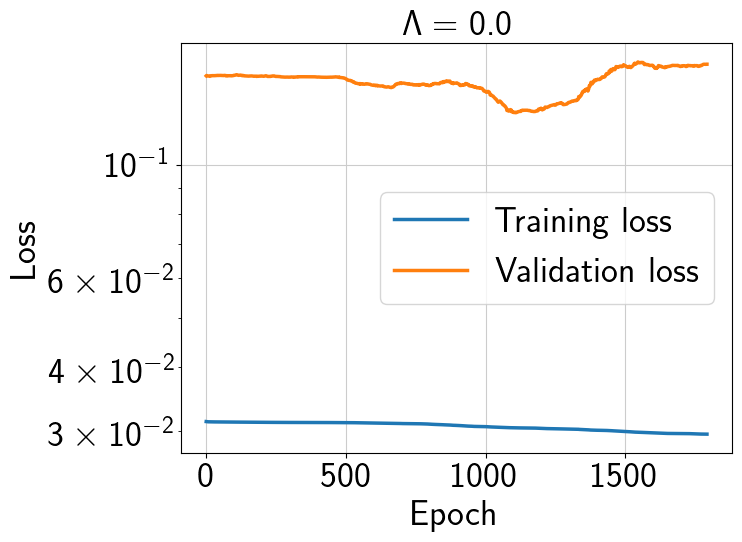

In [150]:
# # instantaneous elastic mode
# S_e  = model_full.get_layer('S_infy').output
# F    = model_full.get_layer('F_input').input
# time = model_full.get_layer('time_input').input
# P_e  = tf.keras.layers.Lambda(lambda x:  tf.matmul(x[0], x[1]))([F, S_e])
# model_fit_e = tf.keras.models.Model([F,time], P_e)


# history, model_fit_e = fit.deterministic(model_fit_e, trainDs, 100, 100, outputFolder, valDs=trainDs, Maxwell_monitor=None, loss=tf.keras.losses.MeanSquaredError())
# model_fit_e.trainable = False
# Plots.plot_stress(model_fit_e, instDs, instDs, outputFolder)
# Plots.plot_elastic_stress_biaxial(model_fit_e, instDs, instDs, outputFolder)

#%% Fit
normalized_error = False
stochastic = False

Maxwell_monitor = None # Callbacks.NonZeroWeightsMonitor(numTens, lambda_prony)
reg_callback = Callbacks.RegularizationCallback(lambda_maxwell, numTens)

if normalized_error == True:
    # loss = tf.keras.losses.MeanAbsolutePercentageError()
    loss = fit.NormalizedLoss()  
else:
    # loss = tf.keras.losses.MeanSquaredError()
    loss = fit.WeightedLoss()


# stochastic optimizer
if stochastic:

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm, name='optimizer')
    
    #Outputs.saveOptimizerConfig(optimizer, outputFolder=outputFolder)
    #Outputs.saveModelConfig(model_fit, outputFolder=outputFolder) 
    
    # tf.keras.backend.set_value(model_fit.optimizer.learning_rate, 0.1)
    model_fit.compile(
            optimizer=optimizer,
            loss=loss,
            run_eagerly=False
        )
    
    with tf.device('/device:CPU:0'):
        history, model_fit =  fit.stochastic(model_fit, trainDs, EPOCHS, earlyStopPatience, outputFolder, valDs=valDs, Maxwell_monitor=Maxwell_monitor)
                                    
# deterministic optimizer
else:
    with tf.device('/device:CPU:0'):
        history, model_fit = fit.deterministic(model_fit, trainDs, EPOCHS, earlyStopPatience, outputFolder, valDs=valDs, Maxwell_monitor=Maxwell_monitor, loss=loss)


#%%    
Outputs.saveLoss(history, Maxwell_monitor=Maxwell_monitor, outputFolder=outputFolder)
Outputs.plotLoss(history, Maxwell_monitor=Maxwell_monitor, title='$\Lambda = {:}$'.format(lambda_maxwell), outputFolder=outputFolder,scale='log')

In [152]:
model_fit.load_weights(outputFolder + '\\ckpt\\ckpt-epoch-1101.ckpt')

In [ ]:
#%% Plot graphs and save model (summary)

# Outputs.showModelSummary(model_fit, outputFolder)
# Outputs.plotModelGraph(model_fit, outputFolder)
Outputs.saveModel(model_fit, outputFolder)

# from exportArchitecture import exportArchitecture
# exportArchitecture(model_fit, outputFolder, weights_local=False)
# exportArchitecture(model_fit, outputFolder, weights_local=True)

#%%
# loadedModel = Outputs.loadModel(outputFolder, 'model', custom_objects=custom_objects)

1/1 [==============================] - 0s 94ms/step


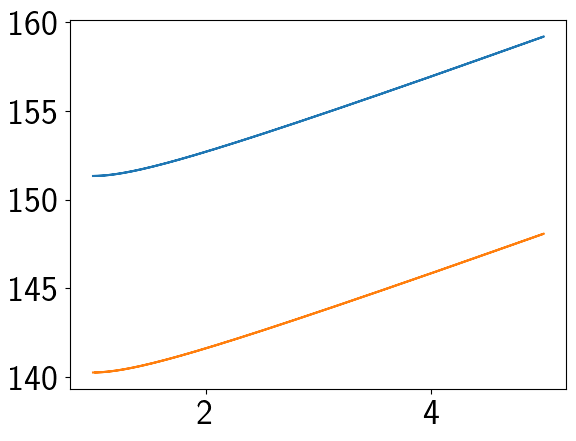

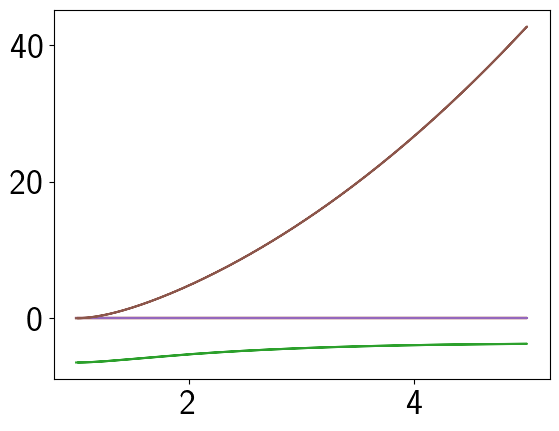

In [181]:
# uniaxial tension
nSteps = 200
stretch_max = 5
stretch_min = 1
lam_dot = 0.1

lam1 = np.linspace(stretch_min,stretch_max,nSteps+1)
dlam = lam1[1]-lam1[0]
lam2 = np.linspace(lam1[-2], stretch_min-dlam, nSteps+1) 
lam = np.concatenate([lam1,lam2])
lam = lam[:-2]

F = np.zeros([1, len(lam), 3, 3])
F[:,:,0,0] = lam
F[:,:,1,1] = 1.0/np.sqrt(lam)
F[:,:,2,2] = 1.0/np.sqrt(lam)


if rateDependent:
    lam_dot_arr = np.ones_like(lam)*lam_dot
    lam_dot_arr[0] = 1.e-6
    F_dot = np.zeros([1, len(lam), 3, 3])
    F_dot[:,:,0,0] = lam_dot_arr
    F_dot[:,:,1,1] = -lam_dot_arr/(2.*lam**(3./2.))
    F_dot[:,:,2,2] = -lam_dot_arr/(2.*lam**(3./2.))

total_time = (stretch_max-stretch_min)/lam_dot*2
time = np.linspace(0,total_time,len(lam)+1)[:-1].reshape(1,-1)


# # simple shear
# nSteps = 300
# stretch_max = 0.5
# stretch_min = 0

# gamma1 = np.linspace(stretch_min,stretch_max,nSteps+1)
# dgamma = gamma1[1]-gamma1[0]
# gamma2 = np.linspace(gamma1[-2], stretch_min-dgamma, nSteps+1) 
# gamma = np.concatenate([gamma1,gamma2])
# F = np.zeros([1, len(gamma)-2, 3, 3])
# F[:,:,0,0] = 1.0
# F[:,:,1,1] = 1.0
# F[:,:,2,2] = 1.0
# F[:,:,0,1] = gamma[:-2]

# stretch_rate = 0.01
# total_time = (stretch_max-stretch_min)/stretch_rate*2
# time = np.linspace(0,total_time,len(gamma)-1)[:-1].reshape(1,-1)

# C_bar_dot = model_fit.get_layer('C_bar_dot').output
# I_dot = model_fit.get_layer('invars_I_bar_dot').output
# J_dot = model_fit.get_layer('invars_J_bar_dot').output
# detC_dot = model_fit.get_layer('invar_det_C_bar_dot').output
# outs = (I_dot, J_dot, detC_dot)

# F_in = model_fit.get_layer('F_input').input
# time_in = model_fit.get_layer('time_input').input
# Fdot_in = model_fit.get_layer('F_dot_input').input
# inp = (F_in,time_in, Fdot_in)

# model_invars_dot = tf.keras.models.Model(inputs=inp, outputs=outs)
# model_C_bar_dot = tf.keras.models.Model(inputs=inp, outputs=C_bar_dot)

if rateDependent:
    inp=[F,time,F_dot]
else:
    inp=[F,time]

if numExtra > 0:
    theta = 40
    extra_input = -np.ones((1, len(lam), numExtra)) *theta/80
    inp.append(extra_input)


# C_bar_dot_out_val = model_C_bar_dot.predict(inp)
# out_val = model_invars_dot.predict(inp)

# np.concatenate(out_val, axis=-1)
# C_bar_dot_out_val

res = model_full.predict(inp)

invars = res[0]
psi_a_0 = model_fit.get_layer('model_psi_a_0').predict([invars,extra_input])
psi = model_fit.get_layer('model_Psi').predict([invars,extra_input])

import matplotlib.pyplot as plt
fig, ax1 = plt.subplots()
ax1.plot(lam, psi[0,:,0])

import matplotlib.pyplot as plt
fig, ax2 = plt.subplots()
ax2.plot(lam, psi_a_0[0,:,0])
ax2.plot(lam, psi_a_0[0,:,1])
ax2.plot(lam, psi_a_0[0,:,2])

if rateDependent:
    inp=[F,time,F_dot]
else:
    inp=[F,time]

if numExtra > 0:
    theta = 80
    extra_input = -np.ones((1, len(lam), numExtra)) *theta/80
    inp.append(extra_input)

res = model_full.predict(inp)

invars = res[0]
psi_a_0 = model_fit.get_layer('model_psi_a_0').predict([invars,extra_input])
psi = model_fit.get_layer('model_Psi').predict([invars,extra_input])

Psi_a = res[-11]

ax1.plot(lam, psi[0,:,0])

ax2.plot(lam, Psi_a[0,:,0])
ax2.plot(lam, Psi_a[0,:,1])
ax2.plot(lam, Psi_a[0,:,2])


In [182]:
n = 1
F[0,n]


S_infty = res[17]
Tau = res[18]
S = res[19][0,n] 
# S_neq = res[39]
dPsi_a_dI_ref = res[26][1]
dPsi_a_dJ_ref = res[27][2]
alpha_a = res[29]
beta_a = res[30]
S_a = res[33]
Q_unstack = res[34]
P = res[35]
# dPsi_a_dI_c = res[-9]
# dPsi_a_dJ_c = res[-8]
# ddPsi_a_ddI_c = res[-7]
# ddPsi_a_ddJ_c = res[-6]
# ddPsi_a_dIdJ_c = res[-5]
# S_ra_neq_bar = res[38]
# dSdCbar = res[35]
# dS_a_dC_bar = res[36]
# dS_a_neq_bar_1, dS_a_neq_bar_2, dS_a_neq_bar_3 = res[-3], res[-2], res[-1]

#Q_unstack[2][0,n]
# time[0,n]
#S_a[0,n]
#Tau[0,n]
# dPsi_a_dI_c[0,n]
# print(S_ra_neq_bar[0,n,0])
# print(dS_a_neq_bar_1[n][0,n])
# print(dS_a_neq_bar_2[n][0,n])
# print(dS_a_neq_bar_3[n][0,n])
Tau[0,n]
# print((dS_a_dC_bar[0][0,n,0,0,:,:] + dS_a_dC_bar[0][0,n,0,0,:,:] + dS_a_dC_bar[0][0,n,0,0,:,:])*2)

# # dQdCbar_2[0][0,0]
# print(dS_a_neq_bar_3[n][0,n,2,2])

# res[20][0][0,n] + res[20][1][0,n] + res[20][2][0,n]
#P[0,n]		TAU(2,1)	1.68698696562000	REAL(8) 


array([0.01598542, 0.29603496, 3.04918465])

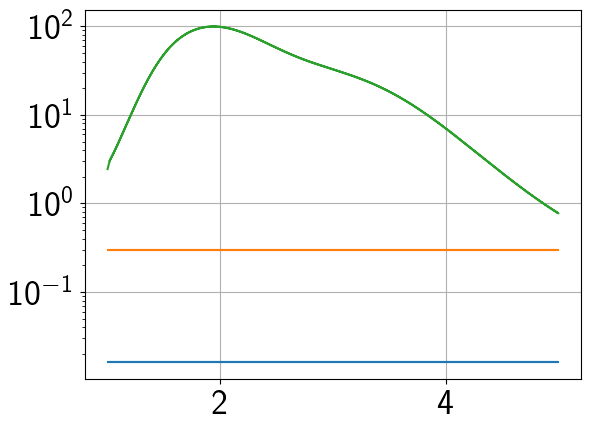

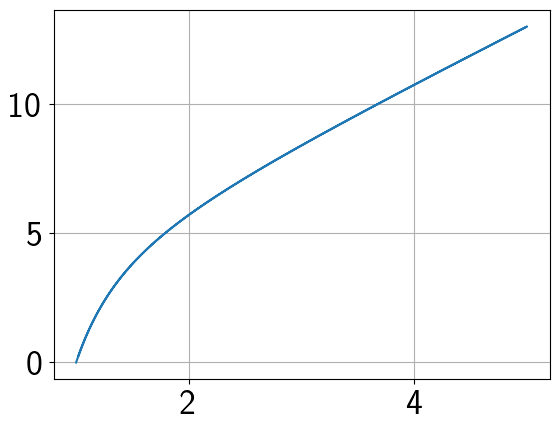

In [183]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(lam,Tau[0,:,0])
ax.plot(lam,Tau[0,:,1])
ax.plot(lam,Tau[0,:,2])
ax.set_yscale('log')
ax.grid(True)

fig, ax = plt.subplots()
ax.plot(lam,S_infty[0,:,0,0]*lam)
ax.grid(True)


1/1 [==============================] - 12s 12s/step


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


1/1 [==============================] - 0s 87ms/step


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


1/1 [==============================] - 0s 85ms/step


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


1/1 [==============================] - 0s 72ms/step


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


1/1 [==============================] - 0s 94ms/step


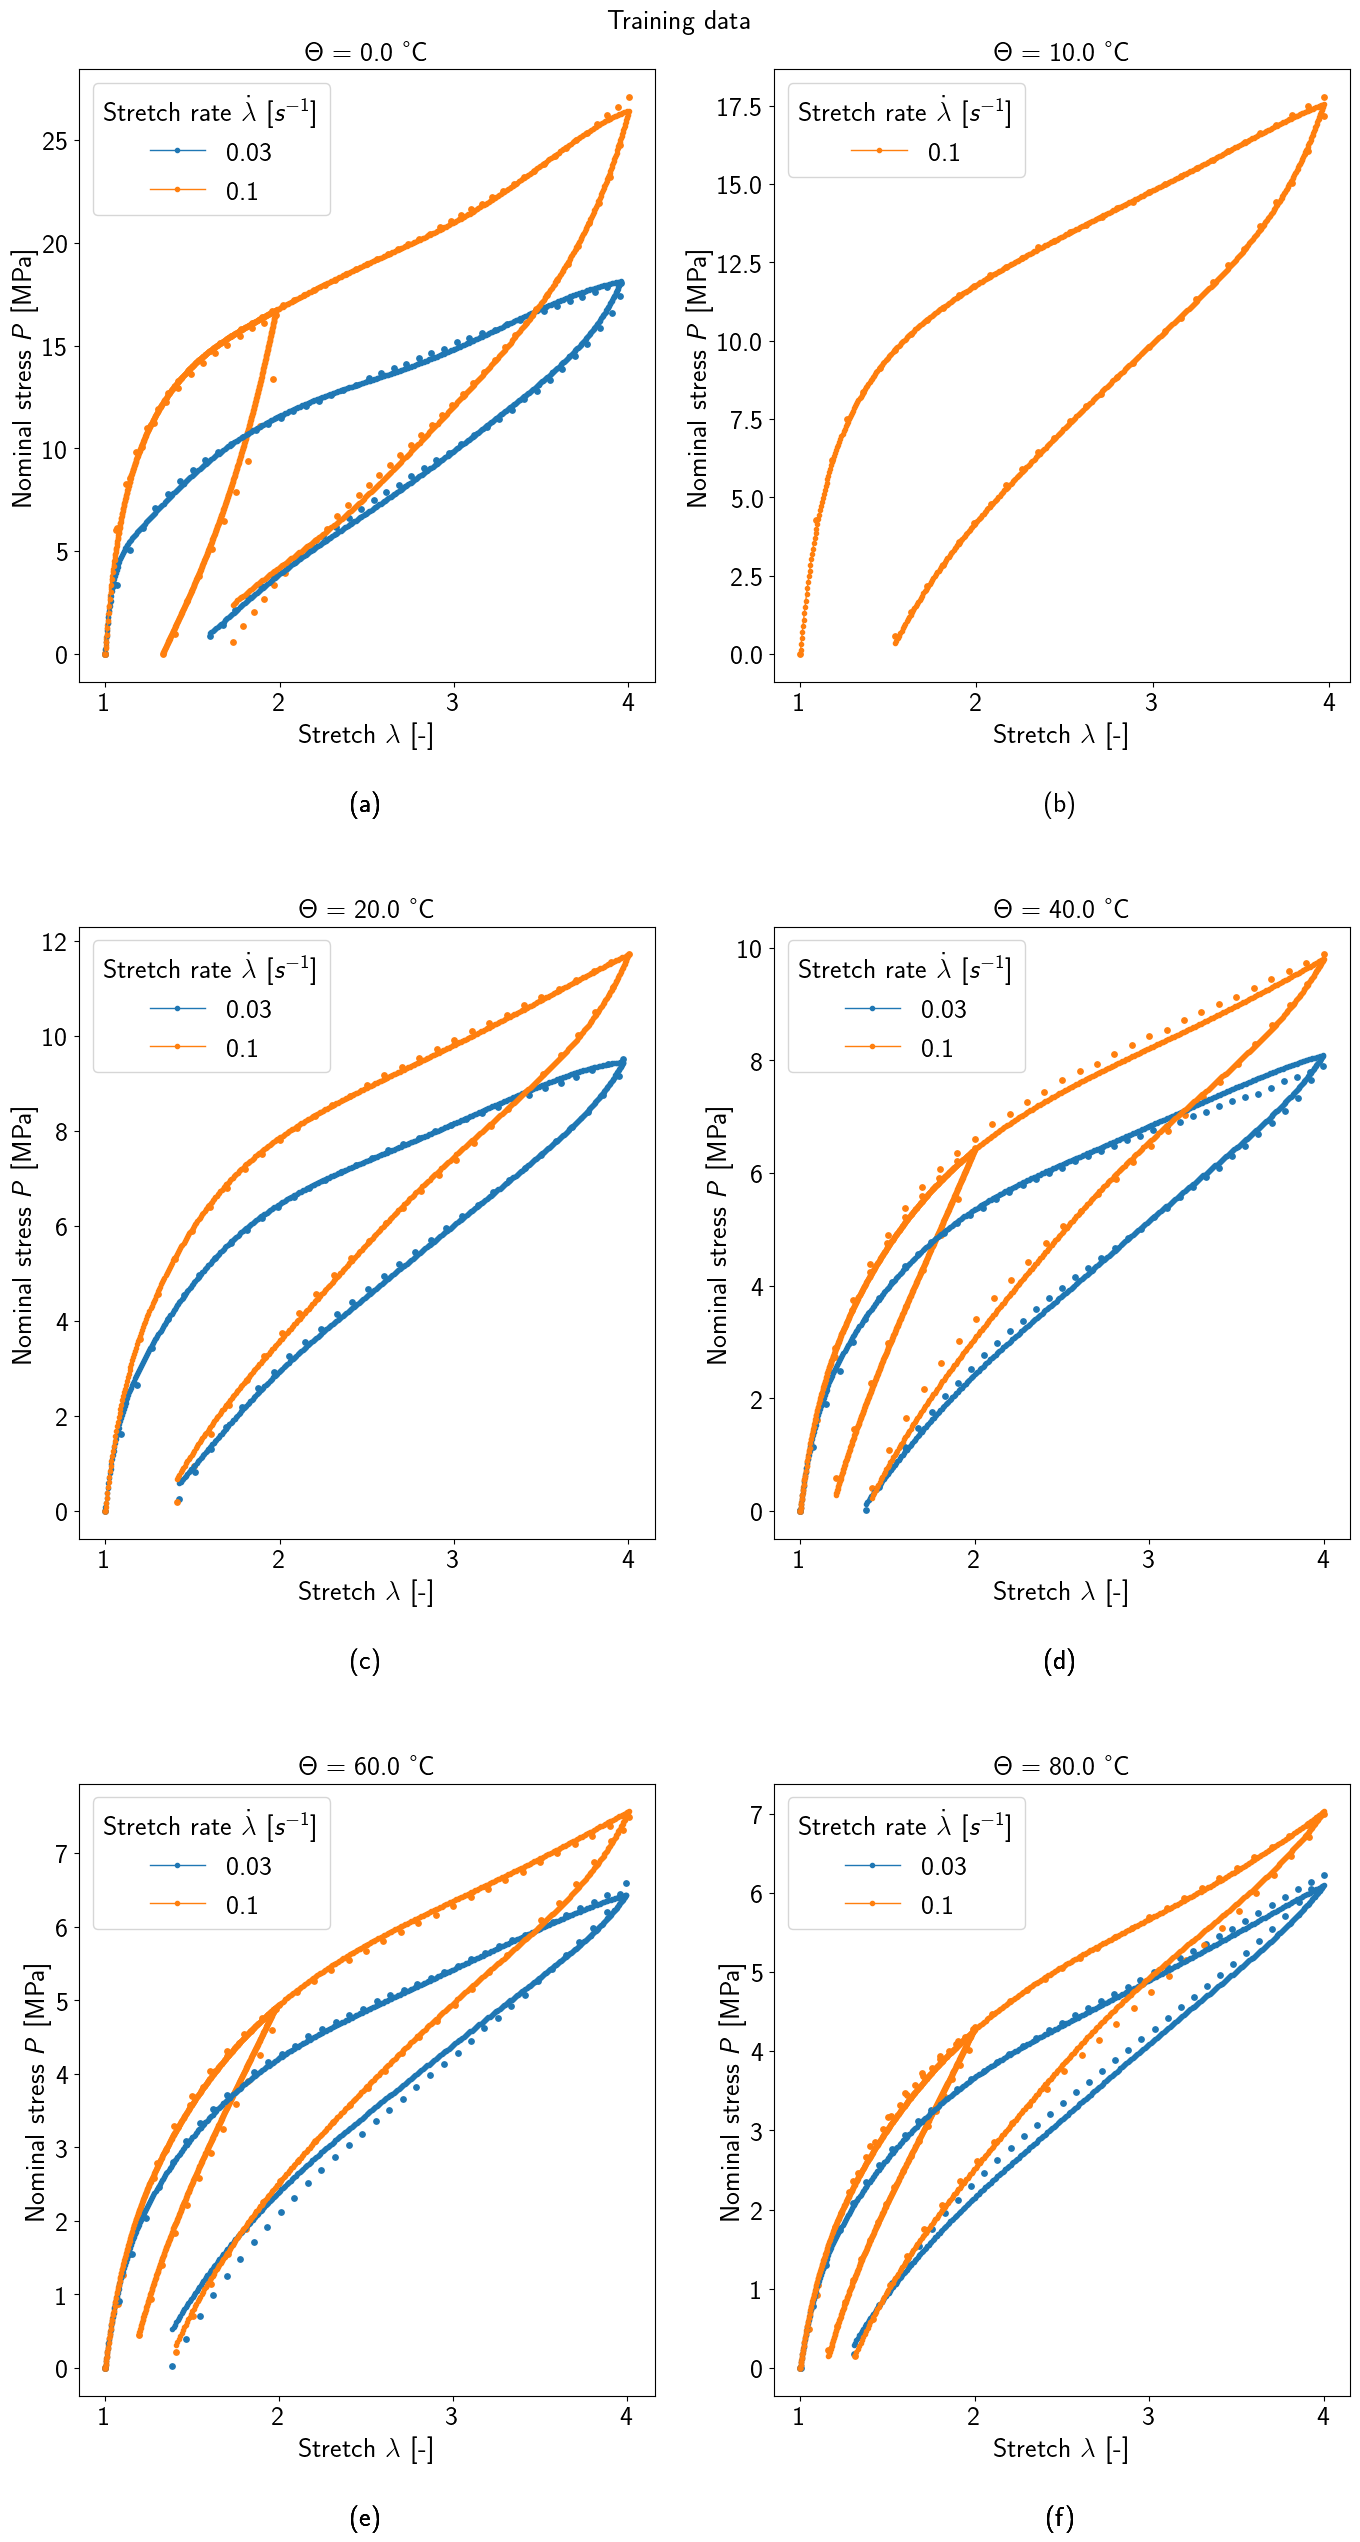

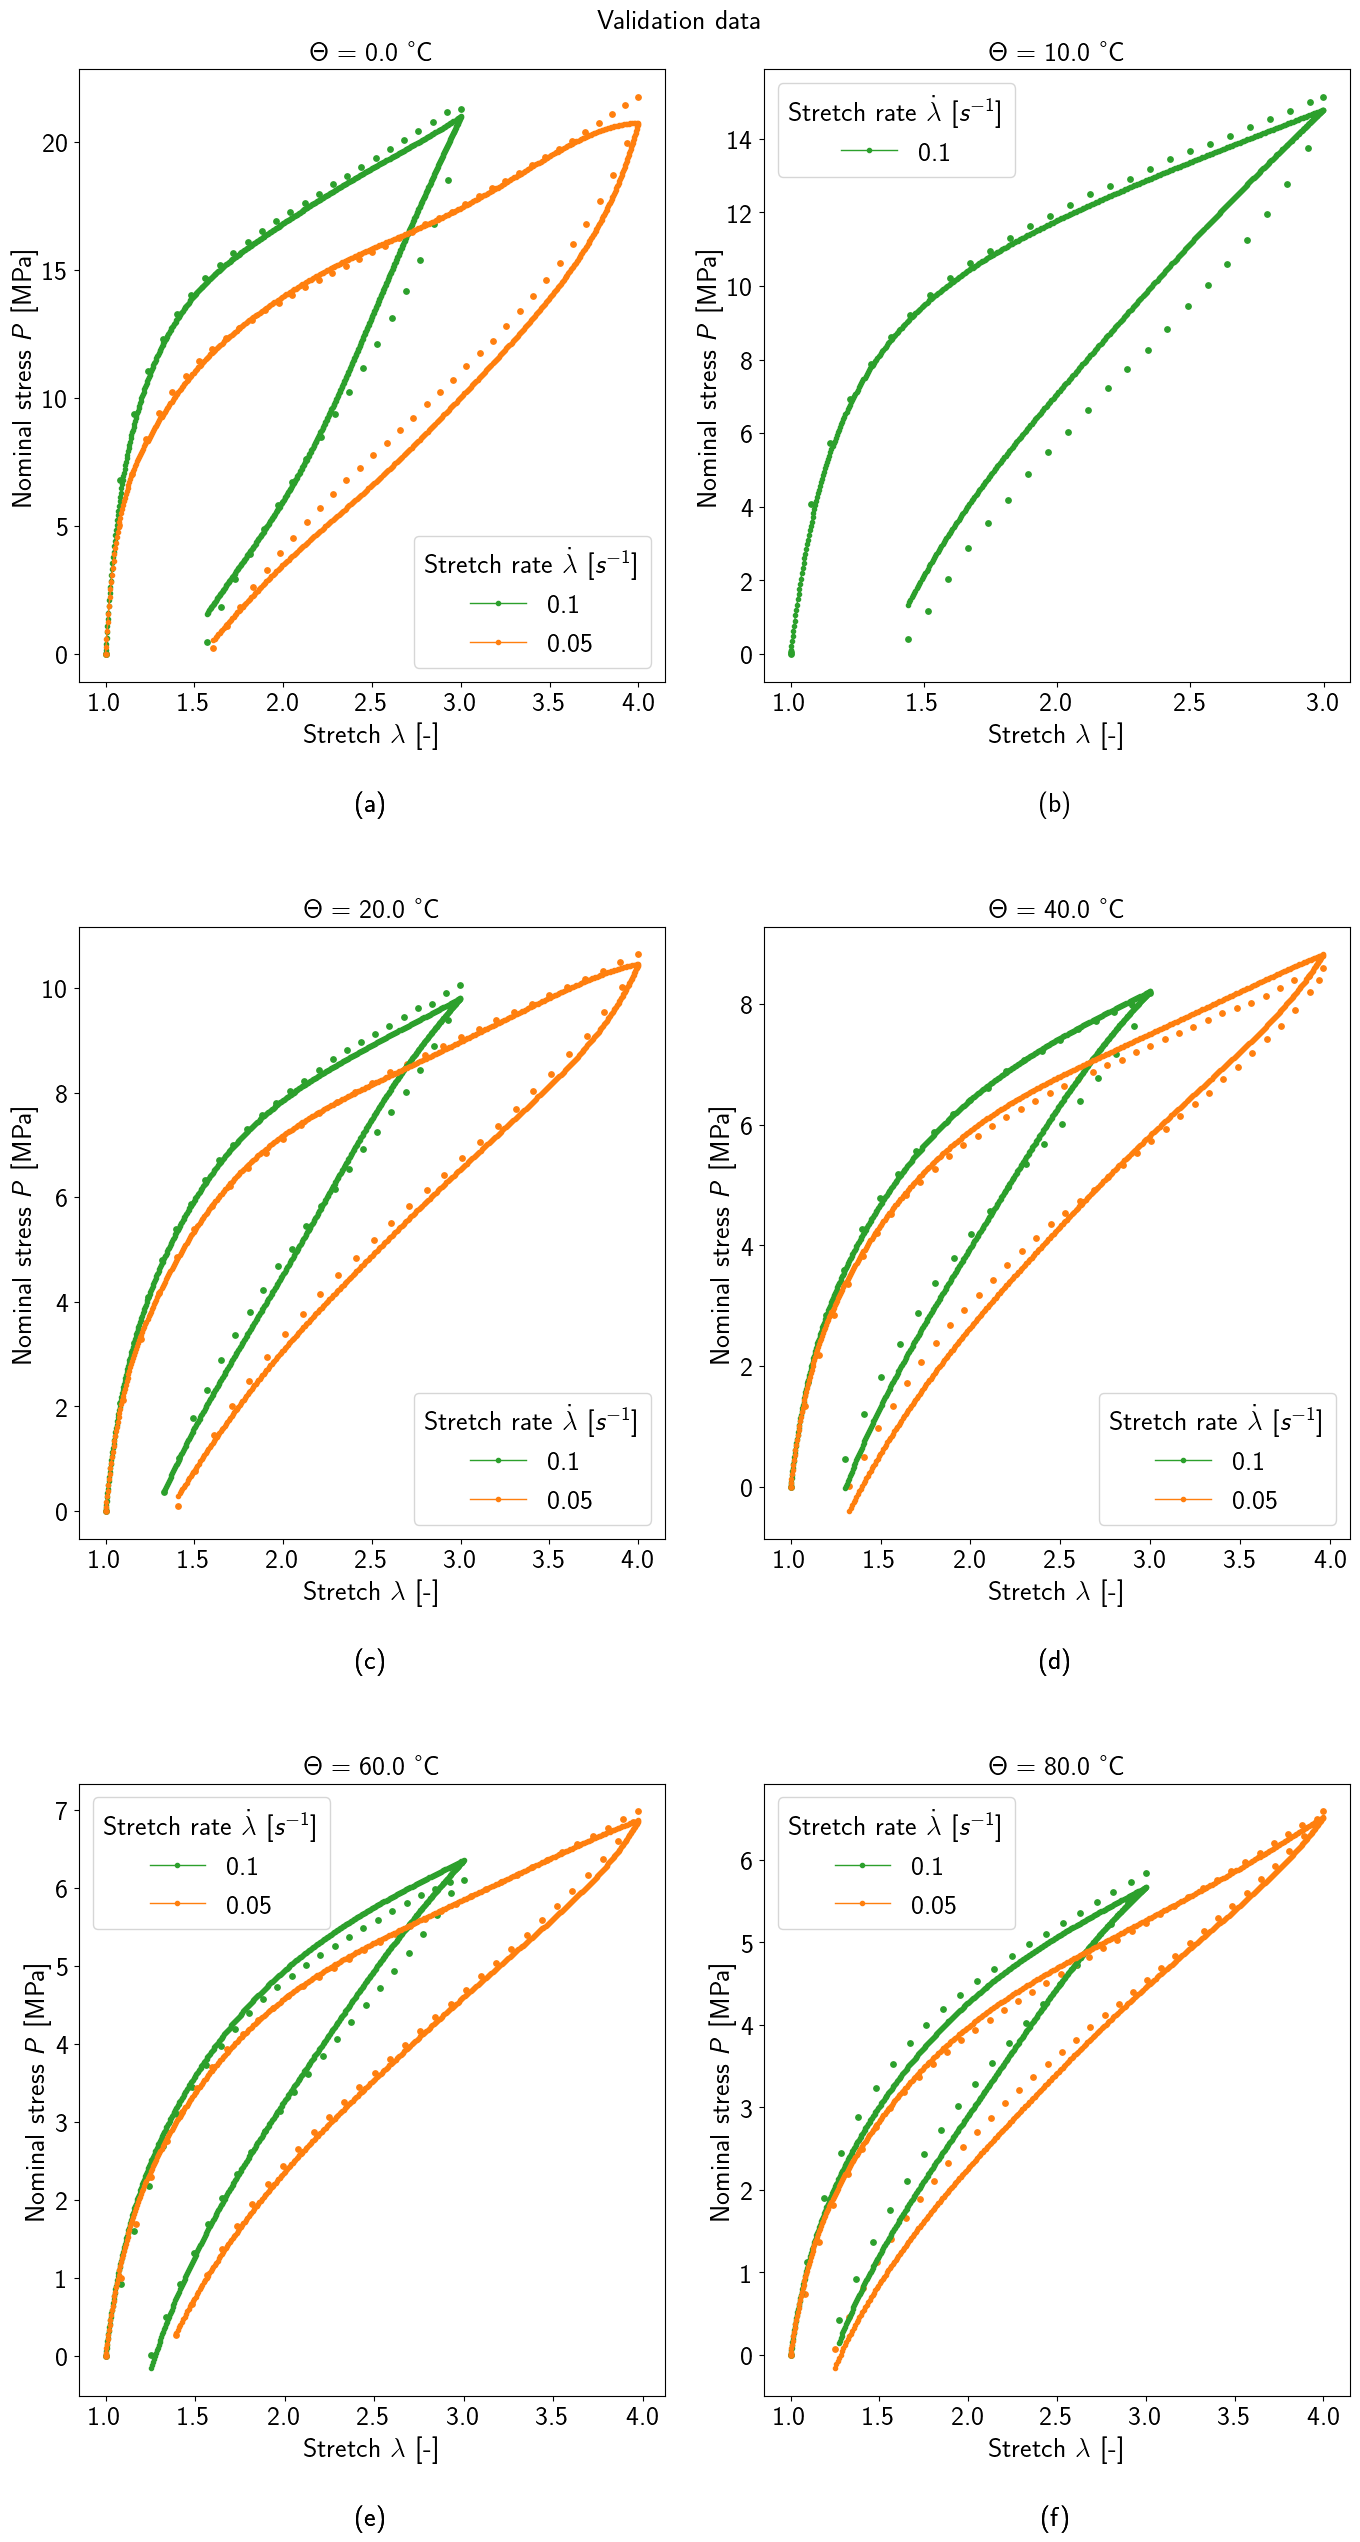

In [9]:
# ckpt = "C:\\Users\\Kian\\Documents\\Projekte\\ViscoCANN\\vCANN\\Results_Hossain\\20251030-185939\\ckpt\\ckpt-epoch-1001.ckpt"
# ckpt = "C:\\Users\\Kian\\Documents\\Projekte\\ViscoCANN\\vCANN\\Results_Hossain\\20251103-190018\\ckpt\\ckpt-epoch-561.ckpt"
# loaded_model = Outputs.loadModel(outputFolder, 'model', custom_objects)
# model_fit.load_weights(ckpt)
#%% individial plotting

# Plots.plot_hossain(model_fit, pathToData, outputFolder, rateDependent)
Plots.plot_vhb_4905(model_fit, pathToData, outputFolder, rateDependent)
    

#%% Structural Tensor
# Plots.plot_struc_tensor(model_fit, plotly=False, outputFolder=outputFolder)

#%% Stress Response 
# Plots.plot_multi_step_isotropic(model_fit, trainDs, outputFolder)
# Plots.plot_stress(model_fit, trainDs, valDs, outputFolder)
# Plots.plot_multi_step(model_fit, trainDs, outputFolder)
# Plots.plot_stress(model_fit, ds_step, ds_step_ref, outputFolder)
        

In [ ]:
from checkpoint_analysis import analyze_checkpoints_from_notebook
analyze_checkpoints_from_notebook(model_fit, pathToData, outputFolder, rateDependent, custom_objects,
                                     checkpoint_dir=None, max_workers=None, use_parallel=True)

ImportError: cannot import name 'analyze_checkpoints_from_notebook' from 'checkpoint_analysis' (c:\Users\Kian\Documents\Projekte\ViscoCANN\vCANN\Nonlinear_Prony_Series_Mullins_General\checkpoint_analysis.py)

In [ ]:
# save model architecture JSON to outputFolder
js = model_fit.to_json()
json_path = os.path.join(outputFolder, 'model_architecture.json')
with open(json_path, 'w', encoding='utf-8') as f:
    f.write(js)
print(f"Model JSON saved to: {json_path}")

Model JSON saved to: C:\Users\Kian\Documents\Projekte\ViscoCANN\vCANN\Results_Liao_Thermo\20251125-015147\model_architecture.json


In [ ]:
# create model from saved JSON architecture
json_path = os.path.join(outputFolder, 'model_architecture.json')

with open(json_path, 'r', encoding='utf-8') as f:
    model_json = f.read()

# custom_objects is defined in an earlier cell
try:
    model_from_json = tf.keras.models.model_from_json(model_json, custom_objects=custom_objects)
except Exception as e:
    # helpful error if custom object registration is missing
    print("Failed to create model from JSON. Error:", e)
    print("Ensure all custom objects are present in `custom_objects` dict:", list(custom_objects.keys()))
    raise

print("Model created from JSON:")
model_from_json.summary()

Model created from JSON:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 F_input (InputLayer)           [(None, 300, 3, 3)]  0           []                               
                                                                                                  
 tf.compat.v1.shape (TFOpLambda  (4,)                0           ['F_input[0][0]']                
 )                                                                                                
                                                                                                  
 tf.__operators__.getitem (Slic  ()                  0           ['tf.compat.v1.shape[0][0]']     
 ingOpLambda)                                                                                     
                                                                     

In [ ]:
from checkpoint_analysis import parallel_checkpoint_analysis
parallel_checkpoint_analysis(model_fit, pathToData, outputFolder, rateDependent, checkpoint_dir=None, max_workers=None)

Found 75 checkpoints to process
Using 24 parallel workers
Processing checkpoints in parallel...
  ✓ Success Epoch 21
  ✓ Success Epoch 41
  ✓ Success Epoch 61
  ✓ Success Epoch 81
  ✓ Success Epoch 101
  ✓ Success Epoch 121
  ✓ Success Epoch 141
  ✓ Success Epoch 161
  ✓ Success Epoch 181
  ✓ Success Epoch 201
  ✓ Success Epoch 221
  ✓ Success Epoch 241
  ✓ Success Epoch 261
  ✓ Success Epoch 281
  ✓ Success Epoch 301
  ✓ Success Epoch 321
  ✓ Success Epoch 341
  ✓ Success Epoch 361
  ✓ Success Epoch 381
  ✓ Success Epoch 401
  ✓ Success Epoch 421
  ✓ Success Epoch 441
  ✓ Success Epoch 461
  ✓ Success Epoch 481
  ✓ Success Epoch 501
  ✓ Success Epoch 521
  ✓ Success Epoch 541
  ✓ Success Epoch 561
  ✓ Success Epoch 581
  ✓ Success Epoch 601
  ✓ Success Epoch 621
  ✓ Success Epoch 641
  ✓ Success Epoch 661
  ✓ Success Epoch 681
  ✓ Success Epoch 701
  ✓ Success Epoch 721
  ✓ Success Epoch 741
  ✓ Success Epoch 761
  ✓ Success Epoch 781
  ✓ Success Epoch 801
  ✓ Success Epoch 821
  ✓ Su

{21: {'success': True,
  'error': None,
  'checkpoint_path': 'C:\\Users\\Kian\\Documents\\Projekte\\ViscoCANN\\vCANN\\Results_Liao_Thermo\\20251125-015147\\ckpt\\ckpt-epoch-21.ckpt',
  'output_folder': 'C:\\Users\\Kian\\Documents\\Projekte\\ViscoCANN\\vCANN\\Results_Liao_Thermo\\20251125-015147\\checkpoint_analysis\\epoch_0021'},
 41: {'success': True,
  'error': None,
  'checkpoint_path': 'C:\\Users\\Kian\\Documents\\Projekte\\ViscoCANN\\vCANN\\Results_Liao_Thermo\\20251125-015147\\ckpt\\ckpt-epoch-41.ckpt',
  'output_folder': 'C:\\Users\\Kian\\Documents\\Projekte\\ViscoCANN\\vCANN\\Results_Liao_Thermo\\20251125-015147\\checkpoint_analysis\\epoch_0041'},
 61: {'success': True,
  'error': None,
  'checkpoint_path': 'C:\\Users\\Kian\\Documents\\Projekte\\ViscoCANN\\vCANN\\Results_Liao_Thermo\\20251125-015147\\ckpt\\ckpt-epoch-61.ckpt',
  'output_folder': 'C:\\Users\\Kian\\Documents\\Projekte\\ViscoCANN\\vCANN\\Results_Liao_Thermo\\20251125-015147\\checkpoint_analysis\\epoch_0061'},
 81:

In [ ]:
from checkpoint_analysis import create_video_from_checkpoint_analysis
video_folder = "C:\\Users\\Kian\\Documents\\Projekte\\ViscoCANN\\vCANN\\Results_Liao_Thermo\\20251125-015147"
create_video_from_checkpoint_analysis(video_folder, fps=2, duration_per_frame=0.5)

Found 75 epoch directories
Found 75 PDF files to convert
Converting PDFs to images...
  Converted 10/75 PDFs
  Converted 20/75 PDFs
  Converted 30/75 PDFs
  Converted 40/75 PDFs
  Converted 50/75 PDFs
  Converted 60/75 PDFs
  Converted 70/75 PDFs
Successfully converted 75 PDFs to images
Video dimensions: 2100x3900
Creating video...
  Added frames for 10/75 images
  Added frames for 20/75 images
  Added frames for 30/75 images
  Added frames for 40/75 images
  Added frames for 50/75 images
  Added frames for 60/75 images
  Added frames for 70/75 images
Video created successfully:
  Path: C:\Users\Kian\Documents\Projekte\ViscoCANN\vCANN\Results_Liao_Thermo\20251125-015147\checkpoint_analysis\training_progress_video.mp4
  Size: 54.2 MB
  Duration: 37.5 seconds
  Total frames: 75
  Epochs included: 75


'C:\\Users\\Kian\\Documents\\Projekte\\ViscoCANN\\vCANN\\Results_Liao_Thermo\\20251125-015147\\checkpoint_analysis\\training_progress_video.mp4'